![dvd_image](dvd_image.jpg)

A DVD rental company needs your help! They want to figure out how many days a customer will rent a DVD for based on some features and has approached you for help. They want you to try out some regression models which will help predict the number of days a customer will rent a DVD for. The company wants a model which yeilds a MSE of 3 or less on a test set. The model you make will help the company become more efficient inventory planning.

The data they provided is in the csv file `rental_info.csv`. It has the following features:
- `"rental_date"`: The date (and time) the customer rents the DVD.
- `"return_date"`: The date (and time) the customer returns the DVD.
- `"amount"`: The amount paid by the customer for renting the DVD.
- `"amount_2"`: The square of `"amount"`.
- `"rental_rate"`: The rate at which the DVD is rented for.
- `"rental_rate_2"`: The square of `"rental_rate"`.
- `"release_year"`: The year the movie being rented was released.
- `"length"`: Lenght of the movie being rented, in minuites.
- `"length_2"`: The square of `"length"`.
- `"replacement_cost"`: The amount it will cost the company to replace the DVD.
- `"special_features"`: Any special features, for example trailers/deleted scenes that the DVD also has.
- `"NC-17"`, `"PG"`, `"PG-13"`, `"R"`: These columns are dummy variables of the rating of the movie. It takes the value 1 if the move is rated as the column name and 0 otherwise. For your convinience, the reference dummy has already been dropped.

In [85]:
#Import python libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error as MSE


In [86]:
#Load data

df = pd.read_csv('rental_info.csv')
df.head()

,rental_date,return_date,amount,release_year,rental_rate,length,replacement_cost,special_features,NC-17,PG,PG-13,R,amount_2,length_2,rental_rate_2
0,2005-05-25 02:54:33+00:00,2005-05-28 23:40:33+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401
1,2005-06-15 23:19:16+00:00,2005-06-18 19:24:16+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401
2,2005-07-10 04:27:45+00:00,2005-07-17 10:11:45+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401
3,2005-07-31 12:06:41+00:00,2005-08-02 14:30:41+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401
4,2005-08-19 12:30:04+00:00,2005-08-23 13:35:04+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401


In [87]:
#Basic EDA

df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rental_date       15861 non-null  object 
 1   return_date       15861 non-null  object 
 2   amount            15861 non-null  float64
 3   release_year      15861 non-null  float64
 4   rental_rate       15861 non-null  float64
 5   length            15861 non-null  float64
 6   replacement_cost  15861 non-null  float64
 7   special_features  15861 non-null  object 
 8   NC-17             15861 non-null  int64  
 9   PG                15861 non-null  int64  
 10  PG-13             15861 non-null  int64  
 11  R                 15861 non-null  int64  
 12  amount_2          15861 non-null  float64
 13  length_2          15861 non-null  float64
 14  rental_rate_2     15861 non-null  float64
dtypes: float64(8), int64(4), object(3)
memory usage: 1.8+ MB


rental_date         0
return_date         0
amount              0
release_year        0
rental_rate         0
length              0
replacement_cost    0
special_features    0
NC-17               0
PG                  0
PG-13               0
R                   0
amount_2            0
length_2            0
rental_rate_2       0
dtype: int64

In [88]:
#Feature engineering

#Convert date column to datetime
df['rental_date'] = pd.to_datetime(df['rental_date'])
df['return_date'] = pd.to_datetime(df['return_date'])

#Target variable: rental length in days
df['rental_length_days'] = (df['return_date'] - df['rental_date']).dt.days
df

#Binary indicators from special features
df['deleted_scenes'] = np.where(df['special_features'].str.contains('Deleted Scenes'), 1, 0)
df['behind_the_scenes'] = np.where(df['special_features'].str.contains('Behind the Scenes'), 1, 0)

df.head()

,rental_date,return_date,amount,release_year,rental_rate,length,replacement_cost,special_features,NC-17,PG,PG-13,R,amount_2,length_2,rental_rate_2,rental_length_days,deleted_scenes,behind_the_scenes
0,2005-05-25 02:54:33+00:00,2005-05-28 23:40:33+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401,3,0,1
1,2005-06-15 23:19:16+00:00,2005-06-18 19:24:16+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401,2,0,1
2,2005-07-10 04:27:45+00:00,2005-07-17 10:11:45+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401,7,0,1
3,2005-07-31 12:06:41+00:00,2005-08-02 14:30:41+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401,2,0,1
4,2005-08-19 12:30:04+00:00,2005-08-23 13:35:04+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401,4,0,1


In [89]:
#Feature / Target split

FEATURES = ['amount',
               'release_year',
               'rental_rate',
               'length',
               'replacement_cost',
               'NC-17',
               'PG',
               'PG-13',
               'R',
               'amount_2',
               'length_2',
               'rental_rate_2',
               'deleted_scenes',
               'behind_the_scenes'
]

X = df[FEATURES]
y = df['rental_length_days']


In [90]:
#Train - test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 9
)

In [91]:
#Model Pipelines

pipelines = {
    'Linear Regression' : Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge Regression' : Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha = 0.1))
    ]),
    'Lasso Regression' : Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha = 0.1))
    ]),
    'Decision Tree' : Pipeline([
        ('model', DecisionTreeRegressor(
            max_depth = 8,
            min_samples_leaf = 0.13,
            random_state = 3
        ))
    ]),
    'Random Forest' : Pipeline([
        ('model', RandomForestRegressor(
            n_estimators = 200,
            random_state = 42
        ))
    ]),
    'Gradient Boosting' : Pipeline([
        ('model', GradientBoostingRegressor(
            n_estimators = 200,
            random_state = 2
        ))
    ])
}


In [92]:
#Model evaluation (test set)

#Initialize variables
results = []
best_mse = float('inf')
best_model = None
best_model_name = None

for name, pipeline in pipelines.items():
    #Fit pipeline
    pipeline.fit(X_train, y_train)

    #Predict
    y_pred = pipeline.predict(X_test)

    #Evaluate
    mse = MSE(y_test, y_pred)

    #Result
    results.append((name, mse))
    print(f'{name}: Test MSE = {mse: .3f}')

    #Select best model
    if mse < best_mse:
        best_mse = mse
        best_model = pipeline
        best_model_name = name


Linear Regression: Test MSE =  2.942
Ridge Regression: Test MSE =  2.942
Lasso Regression: Test MSE =  3.078
Decision Tree: Test MSE =  3.322
Random Forest: Test MSE =  2.025
Gradient Boosting: Test MSE =  2.322


In [93]:
#Final recommendation 

print('\nRecommended model')
print(f'Best model: {best_model_name}')
print(f'Best Test MSE: {best_mse: .3f}')

pd.DataFrame(results, columns = ['Model', 'Test MSE']).sort_values('Test MSE')


Recommended model
Best model: Random Forest
Best Test MSE:  2.025


,Model,Test MSE
4,Random Forest,2.025288
5,Gradient Boosting,2.322357
0,Linear Regression,2.941724
1,Ridge Regression,2.941738
2,Lasso Regression,3.078465
3,Decision Tree,3.321503


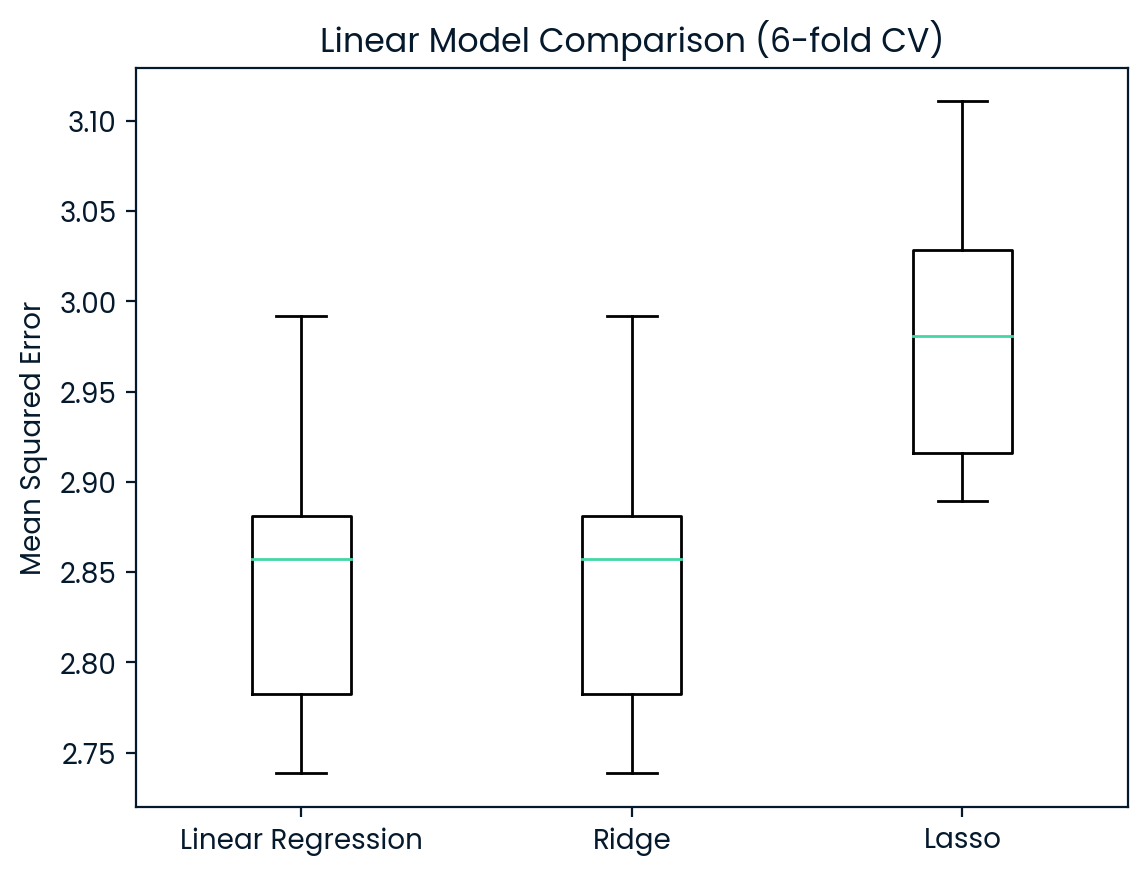

In [94]:
#Cross-validation (Linear models)

linear_models = {
    'Linear Regression' : LinearRegression(),
    'Ridge' : Ridge(alpha = 0.1),
    'Lasso' : Lasso(alpha = 0.1)
}

kf = KFold(n_splits = 6, shuffle = True, random_state = 42)
cv_results = []
labels = []

#Loop through the models' values
for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    #Perform cross-validation
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv = kf,
        scoring = 'neg_mean_squared_error'
    )

    #Append the results - convert to positive MSE
    cv_results.append(-cv_scores)
    labels.append(name)

#Create a boxplot of the results
plt.boxplot(cv_results, labels = labels)
plt.ylabel('Mean Squared Error')
plt.title('Linear Model Comparison (6-fold CV)')
plt.show()
 
    

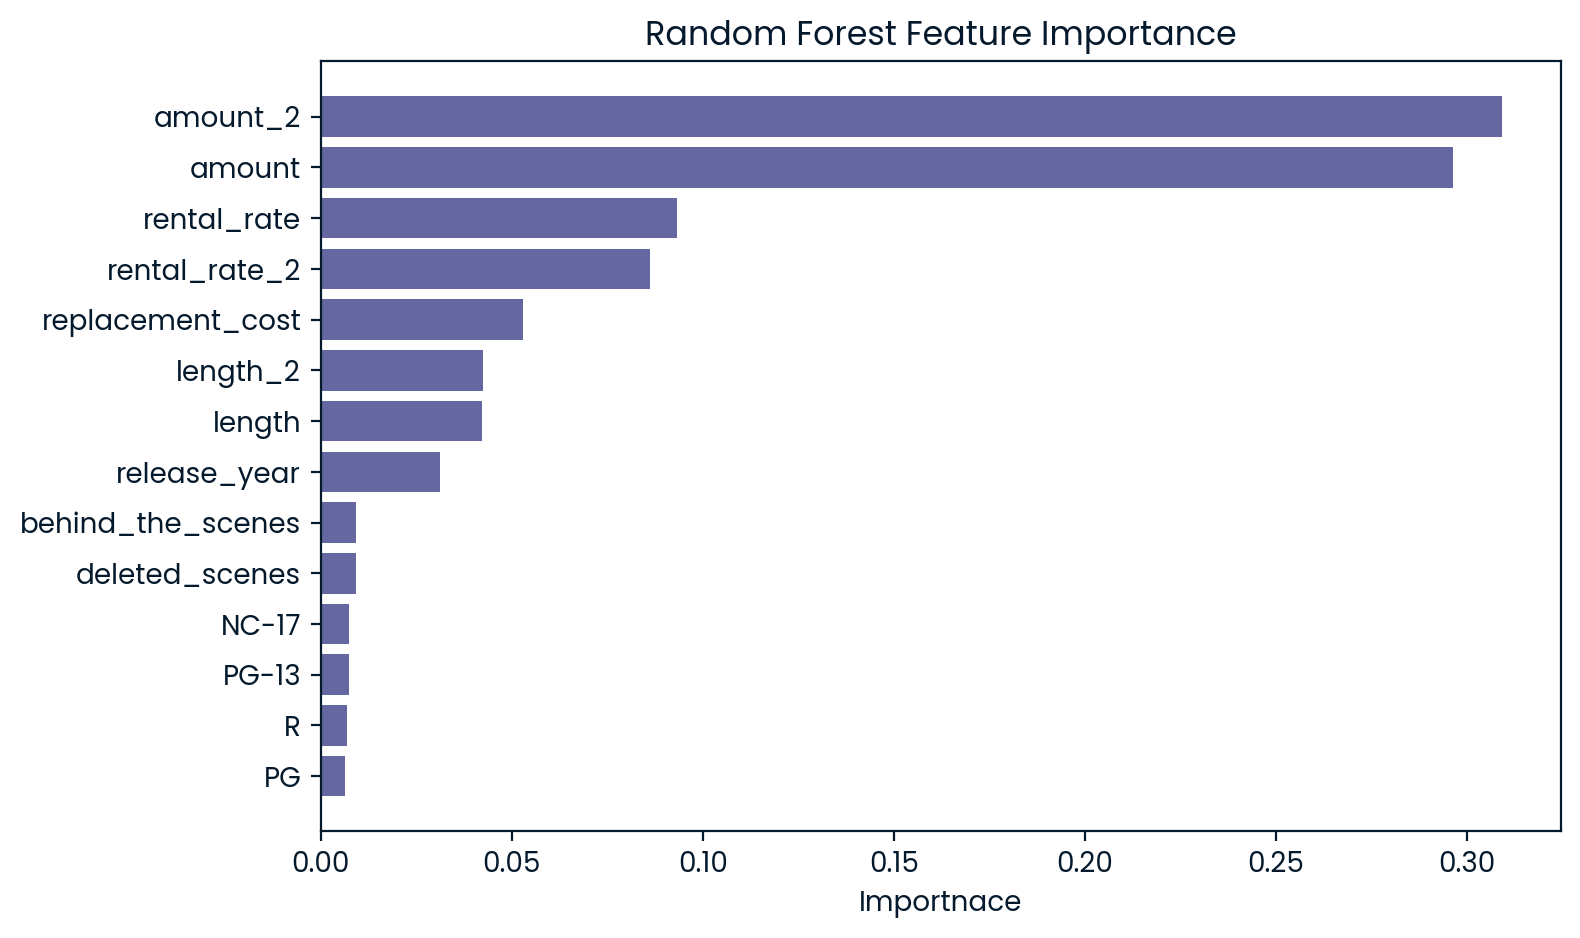

,Feature,Importance
6,PG,0.006431
8,R,0.006987
7,PG-13,0.007334
5,NC-17,0.007410
12,deleted_scenes,0.009174
13,behind_the_scenes,0.009344
1,release_year,0.031095
3,length,0.042266
10,length_2,0.042484
4,replacement_cost,0.052874


In [95]:
#Feature importance - Random forest

#Model, fit
rf_model = pipelines['Random Forest']
rf_model.fit(X_train, y_train)

#Feature importance
rf_importances = rf_model.named_steps['model'].feature_importances_

#Create DataFrame
rf_importance_df = pd.DataFrame({
    'Feature' : FEATURES,
    'Importance' : rf_importances
}).sort_values('Importance', ascending = True)

#Create horizontal bargraph
plt.figure(figsize = (8, 5))
plt.barh(
    rf_importance_df['Feature'],
    rf_importance_df['Importance']
)
plt.xlabel('Importnace')
plt.title('Random Forest Feature Importance')
plt.show()

rf_importance_df

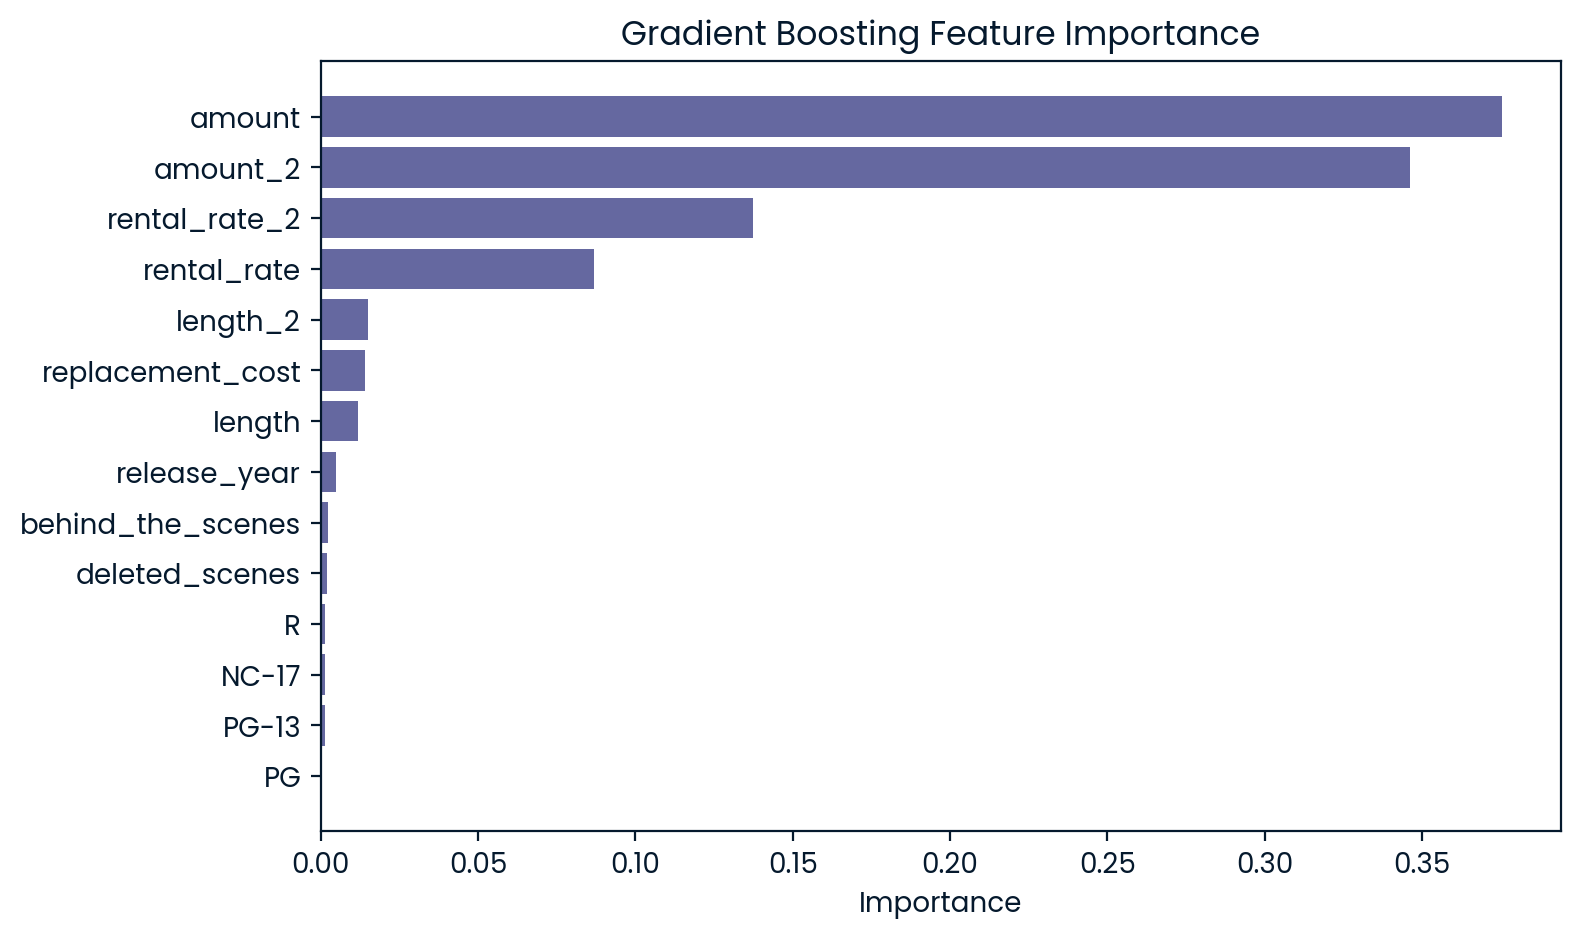

,Feature,Importance
6,PG,0.000374
7,PG-13,0.001236
5,NC-17,0.001258
8,R,0.001468
12,deleted_scenes,0.001883
13,behind_the_scenes,0.002314
1,release_year,0.004930
3,length,0.011862
4,replacement_cost,0.014011
10,length_2,0.014942


In [96]:
#Feature importance - Gradient boosting

#Model, fit
gb_model = pipelines['Gradient Boosting']
gb_model.fit(X_train, y_train)

#Feature importance
gb_importances = gb_model.named_steps['model'].feature_importances_

#Create DataFrame
gb_importance_df = pd.DataFrame({
    'Feature' : FEATURES,
    'Importance' : gb_importances
}).sort_values('Importance', ascending = True)

#Create horizontal bargraph
plt.figure(figsize = (8, 5))
plt.barh(
    gb_importance_df['Feature'],
    gb_importance_df['Importance']
)
plt.xlabel('Importance')
plt.title('Gradient Boosting Feature Importance')
plt.show()

gb_importance_df

# Notes

## Notes: Regression Models and Evaluation

### Lasso and Ridge Regression

Lasso and Ridge regressions are types of **Linear Regression** that apply
regularisation to penalise model complexity.

- Both add a penalty term to the loss function
- The penalty helps prevent overfitting

**Alpha parameter:**

- `alpha = 0` → equivalent to standard Linear Regression
- `alpha = 0.1` (closer to zero) → weak penalisation
- Larger `alpha` → stronger penalisation

**Important:**
Lasso and Ridge regression require `StandardScaler()` for meaningful results
because the penalty term is sensitive to feature scale.

---

## Methods for Data Splitting in scikit-learn

### train_test_split()

This function **randomly shuffles** the dataset and splits it into
training and testing sets (e.g. 80/20).

**Pros**
- Extremely fast
- Computationally cheap
- Ideal for very large datasets

**Cons**
- Prone to “lucky” or “unlucky” splits
- Test performance may be misleading if the split is unrepresentative

**When to use**
- Large datasets (hundreds of thousands of rows)
- Memory- or time-intensive models

---

### K-Fold Cross-Validation (KFold)

K-Fold splits the dataset into `K` equal parts.

- The model is trained `K` times
- Each fold is used once as the test set

**Pros**
- Very robust evaluation
- Reduces variance caused by random splits
- Every data point is used for both training and testing

**Cons**
- Computationally expensive
- Training time increases by a factor of `K`

**When to use**
- Smaller datasets
- When model stability matters

---

## Mean Squared Error (MSE)

MSE measures the **average squared difference** between predicted and true values.

### Why MSE is commonly used on test sets

- **Scale-sensitive:** penalises large errors
- **Mathematically convenient:** differentiable and easy to average
- **Model-agnostic:** usable for any regression model
- **Statistical meaning:** equivalent to maximum likelihood under Gaussian noise

### Models where MSE is appropriate

**Regression models with continuous outputs:**
- Linear, Ridge, Lasso, Polynomial Regression
- Decision Trees, Random Forests, Gradient Boosting
- Support Vector Regression (SVR)
- Neural networks for regression
- Time-series forecasting models

### Models where MSE is NOT appropriate

- Classification models (Logistic Regression, SVM, k-NN, Naive Bayes)

**Reason:**
- Outputs are class labels or probabilities
- Better metrics include accuracy, F1, ROC-AUC, log loss

---

### Feature Importance Analysis

Tree-based models consistently identified pricing variables,
movie length, and rental rate as the strongest predictors of
rental duration.

- Random Forest distributes importance across correlated features (Random Forest captures non-linear interactions and often highlights price- and duration-related variables.)
- Gradient Boosting concentrates importance on the most informative variables (Gradient Boosting tends to focus strongly on the most predictive features, often producing a sharper importance distribution than Random Forest.)

This aligns with domain expectations: rental cost and content length
influence customer rental behaviour.